### 安裝套件

In [40]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

### 匯入資料

In [41]:
file_path='./WB_Machine_Error_Event_0722_0728.xlsx'
df=pd.read_excel(file_path)
#print(df.head())
print(df.shape)

(35607, 14)


### 查看欄位名稱

In [42]:
df.columns

Index(['step_id', 'lot_id', 'equip_type', 'equip_id', 'device_name',
       'recipe_id', 'in_qty', 'ng_qty', 'start_time', 'end_time', 'location',
       'floor', 'eventmessage', 'eventcount'],
      dtype='object')

### eventcount有空值

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35607 entries, 0 to 35606
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   step_id       35607 non-null  object        
 1   lot_id        35607 non-null  object        
 2   equip_type    35607 non-null  object        
 3   equip_id      35607 non-null  object        
 4   device_name   35607 non-null  object        
 5   recipe_id     35607 non-null  object        
 6   in_qty        35607 non-null  int64         
 7   ng_qty        35607 non-null  float64       
 8   start_time    35607 non-null  datetime64[ns]
 9   end_time      35607 non-null  datetime64[ns]
 10  location      35607 non-null  object        
 11  floor         35607 non-null  object        
 12  eventmessage  31510 non-null  object        
 13  eventcount    31510 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(9)
memory usage: 3.8+ MB


In [44]:
#df.describe()

### 將eventcount空值的地方已0呈現，代表發生次數為0

In [45]:
df['eventcount']=df['eventcount'].fillna(0)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35607 entries, 0 to 35606
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   step_id       35607 non-null  object        
 1   lot_id        35607 non-null  object        
 2   equip_type    35607 non-null  object        
 3   equip_id      35607 non-null  object        
 4   device_name   35607 non-null  object        
 5   recipe_id     35607 non-null  object        
 6   in_qty        35607 non-null  int64         
 7   ng_qty        35607 non-null  float64       
 8   start_time    35607 non-null  datetime64[ns]
 9   end_time      35607 non-null  datetime64[ns]
 10  location      35607 non-null  object        
 11  floor         35607 non-null  object        
 12  eventmessage  31510 non-null  object        
 13  eventcount    35607 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(9)
memory usage: 3.8+ MB


### 新增欄位:製造時間、不良率

In [47]:
#製造時間
df["duration_min"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 60 #除以60轉成分鐘
#不良率
df["ng_rate"] = df["ng_qty"].div(df["in_qty"]).where(df["in_qty"] > 0)


### 觀察發生最多次的錯誤事件
EX:在錯誤事件為'PDT-UNEXPECTED-SHTL'之下，總共發生了13764的錯誤次數

In [48]:
event_summary = (
            df.groupby(["eventmessage"], as_index=False)
            .agg(
            event_count=("eventcount", "sum"),
            ))
#event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
event_summary = event_summary.sort_values("event_count",ascending=False)
print(event_summary.head())
print(event_summary.shape)

           eventmessage  event_count
28  PDT-UNEXPECTED-SHTL      13764.0
27  PDT-UNEXPECTED-NSOP      10216.0
20    PBI-WIRE-STOP-ERR       7433.0
26  PDT-UNEXPECTED-NSOL       5065.0
22         PDT-EFO-OPEN       3931.0
(39, 2)


In [49]:
# event_summary = (
#             df.groupby(["eventmessage","step_id","lot_id","equip_id","device_name"], as_index=False)
#             .agg(
#             event_count=("eventcount", "sum"),
#             ng_qty=("ng_qty", "max"),
#             in_qty=("in_qty", "max")
#             ))
# event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
# event_summary = event_summary.sort_values("event_count",ascending=False)
# print(event_summary.head())
# print(event_summary.shape)

In [50]:
# df[(df["eventmessage"]=='EFU open error') & (df['equip_id']=='WB3504')]

### 觀察最高報廢率的錯誤事件
EX:在錯誤事件為'PDT-NO-FS-DETECT'之下，總共發生了200的錯誤次數

In [51]:
# event_summary = (
#             df.groupby("eventmessage", as_index=False)
#             .agg(
#             event_count=("eventcount", "sum"),
#             equip_count=("equip_id", "nunique"),
#             lot_count=("lot_id", "nunique"),
#             ng_qty=("ng_qty", "sum"),
#             in_qty=("in_qty", "sum")
#             ))
# event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
# event_summary = event_summary.sort_values("ng_rate",ascending=False)
# print(event_summary.head())

## 錯誤事件 Pareto 分析

Pareto 分析的目的，是找出少數幾種主要錯誤是否占了大部分事件。
分析結果:前三種錯誤就佔了43.35%，分別為PDT-UNEXPECTED-SHTL、PDT-UNEXPECTED-NSOP、PBI-WIRE-STOP-ERR。

In [52]:
event_pareto = (
df.groupby("eventmessage")["eventcount"]
.sum()
.sort_values(ascending=False)
.reset_index()
)
event_pareto["percentage"] = (event_pareto["eventcount"] /event_pareto["eventcount"].sum())
event_pareto["cumulative_percentage"] = (event_pareto["percentage"].cumsum())
print(event_pareto.head(20))
main_events=event_pareto.loc[:2,['eventmessage']]['eventmessage'].tolist()
print(main_events)

                     eventmessage  eventcount  percentage  \
0             PDT-UNEXPECTED-SHTL     13764.0    0.189940   
1             PDT-UNEXPECTED-NSOP     10216.0    0.140978   
2               PBI-WIRE-STOP-ERR      7433.0    0.102574   
3             PDT-UNEXPECTED-NSOL      5065.0    0.069896   
4                    PDT-EFO-OPEN      3931.0    0.054247   
5             Ball position error      3921.0    0.054109   
6                   No tail error      3680.0    0.050783   
7           Pad nonsticking error      3666.0    0.050590   
8              PDT-WIREFEED-ERROR      3508.0    0.048410   
9          Lead nonsticking error      3383.0    0.046685   
10                 EFU open error      3048.0    0.042062   
11                  EH-PDT-SMBALL      1579.0    0.021790   
12              Spool empty error      1577.0    0.021762   
13             No bump tail error      1556.0    0.021472   
14                Ball size error      1400.0    0.019320   
15             AUTO-VLL-

畫 Pareto 圖

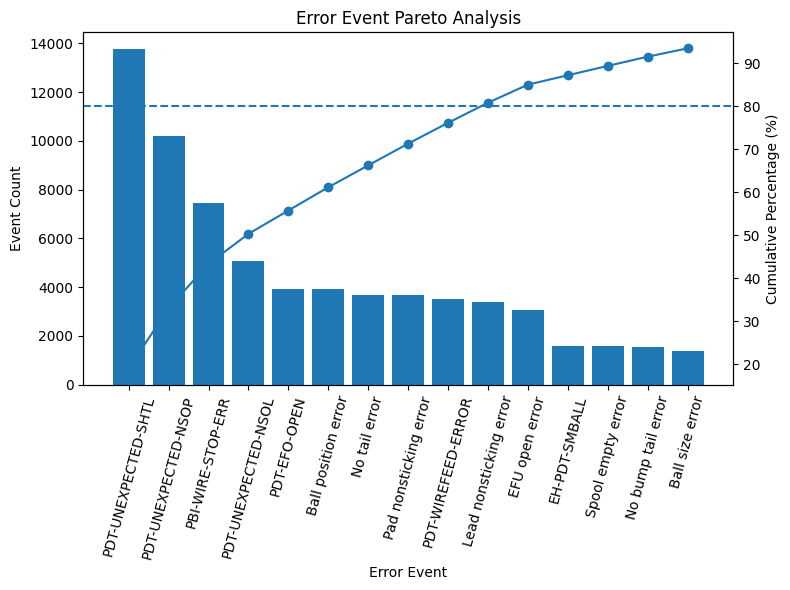

In [53]:
top_n = 15
plot_data = event_pareto.head(top_n)
#plot_data = event_pareto
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(
plot_data["eventmessage"],
plot_data["eventcount"]
)
ax1.set_xlabel("Error Event")
ax1.set_ylabel("Event Count")
ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(
plot_data["eventmessage"],
plot_data["cumulative_percentage"] * 100,
marker="o"
)
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative Percentage (%)")
plt.title("Error Event Pareto Analysis")
plt.tight_layout()
plt.show()

### 在這三個最常發生錯誤的事件下，分別哪些機台最常發生錯誤

In [54]:
event_machine = (
    df.loc[df['eventmessage'].isin(main_events)].groupby(["eventmessage", "equip_id"], as_index=False)
      .agg(
          event_count=("eventcount", "sum")
         # lot_count=("lot_id", "nunique"),
         # ng_qty=("ng_qty", "sum"),
         # in_qty=("in_qty", "sum")
      )
)

# event_machine["ng_rate"] = (
#     event_machine["ng_qty"] / event_machine["in_qty"]
# )
# #重點不要只看錯誤總數，因為產量高的機台錯誤數通常也會比較高。
# #更公平的比較方式是建立「每千投入量錯誤次數」。
# event_machine["events_per_1000"] = (event_machine["event_count"] /event_machine["in_qty"] * 1000)

event_machine = event_machine.sort_values(
    ["eventmessage", "event_count"],
    ascending=[True, False]
)
print(event_machine.groupby("eventmessage", group_keys=False)
    .head(3))
print(event_machine.shape)

             eventmessage equip_id  event_count
454     PBI-WIRE-STOP-ERR  WBK3150         81.0
811     PBI-WIRE-STOP-ERR  WBR2250         67.0
779     PBI-WIRE-STOP-ERR  WBR2205         56.0
1289  PDT-UNEXPECTED-NSOP  WBC6034         74.0
1390  PDT-UNEXPECTED-NSOP  WBC7035         60.0
2152  PDT-UNEXPECTED-NSOP  WBR2259         54.0
2828  PDT-UNEXPECTED-SHTL  WBC7120         98.0
2899  PDT-UNEXPECTED-SHTL  WBC7236         80.0
2812  PDT-UNEXPECTED-SHTL  WBC7035         64.0
(3821, 3)


In [55]:
# check = (
#     df.groupby("equip_id")["device_name"]
#       .nunique()
#       .reset_index(name="device_count")
# )

# print(check)

### 分析錯誤事件與產品間的關係

In [56]:
device_summary = (
df.loc[df['eventmessage'].isin(main_events)].groupby(['eventmessage',"device_name"], as_index=False)
.agg(
event_count=("eventcount", "sum")
# machine_count=("equip_id", "nunique"),
# lot_count=("lot_id", "nunique"),
# in_qty=("in_qty", "sum"),
# ng_qty=("ng_qty", "sum")
)
)
# device_summary["ng_rate"] = (device_summary["ng_qty"] /device_summary["in_qty"])
# device_summary["events_per_1000"] = (device_summary["event_count"] /device_summary["in_qty"] * 1000)
device_summary = device_summary.sort_values(["eventmessage","event_count"],ascending=[True,False])
print(device_summary.groupby("eventmessage", group_keys=False).head(3))

            eventmessage                    device_name  event_count
130    PBI-WIRE-STOP-ERR  Y5BN8ZA64PTP31245-STK-HVM-CIP        568.0
134    PBI-WIRE-STOP-ERR   Y62P8DV32PTP31238-SE-HVM-CIP        402.0
82     PBI-WIRE-STOP-ERR              SCH113BJ2-BB4PA-A        293.0
179  PDT-UNEXPECTED-NSOP       66BJY9T1C28LFAS-N3841-3M        621.0
329  PDT-UNEXPECTED-NSOP  Y5BN8ZA64PTP31245-STK-HVM-CIP        311.0
211  PDT-UNEXPECTED-NSOP      HH28LKT3Y48BA8J-2DIDW636M        282.0
527  PDT-UNEXPECTED-SHTL  Y5BN8ZA64PTP31245-STK-HVM-CIP        738.0
389  PDT-UNEXPECTED-SHTL       66BJY9T1C28LFAS-N3841-3M        398.0
419  PDT-UNEXPECTED-SHTL      HH28LKT3Y48BA8J-2DIDW636M        381.0


在錯誤事件為'PBI-WIRE-STOP-ERR'之下，機型是WBK3150具有最高的event_count。
在錯誤事件為'PBI-WIRE-STOP-ERR'之下，產品是Y5BN8ZA64PTP31245-STK-HVM-CIP 具有最高的event_count。
現在想知道的是，WBK3150是因為Y5BN8ZA64PTP31245-STK-HVM-CIP 才具有最高的events_per_1000，還是不管生產甚麼產品都容易發生?

In [61]:
event = "PDT-UNEXPECTED-SHTL"

# 第一層：整理到 Event × Step × Lot × Machine × Device
event_run_summary = (
    df[df["eventmessage"] == event]
    .groupby(
        [
            "eventmessage",
            "step_id",
            "lot_id",
            "equip_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        # 同一生產單位可能有多列事件，因此錯誤次數加總
        event_count=("eventcount", "sum"),

        # 同一生產單位的 in_qty 重複出現在多列時，只取一次
        in_qty=("in_qty", "max")
    )
)

# 第二層：彙總到 Machine × Device
machine_device_summary = (
    event_run_summary
    .groupby(
        ["equip_id", "device_name"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("event_count", "sum"),
        in_qty=("in_qty", "sum"),
        lot_count=("lot_id", "nunique"),
        production_run_count=("step_id", "size")
    )
)

# 計算每千投入錯誤次數
machine_device_summary["event_per_1000"] = np.where(
    machine_device_summary["in_qty"] > 0,
    machine_device_summary["event_count"]
    / machine_device_summary["in_qty"]
    * 1000,
    np.nan
)

# 依每千投入錯誤次數排序
machine_device_summary = (
    machine_device_summary
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_device_summary.loc[
    :,
    [
        "equip_id",
        "device_name",
        "event_count",
        "in_qty",
        "lot_count",
        "production_run_count",
        "event_per_1000"
    ]
].head(20)

,equip_id,device_name,event_count,in_qty,lot_count,production_run_count,event_per_1000
0,WBR2192,HHB8LKT3Y48BA8J-2DIDW63,32.0,892,1,1,35.874439
1,WB2502,Y5BN8ZA64PTP31245-STK-HVM-CIP,46.0,1508,4,4,30.503979
2,WBR2194,HHB8LKT3Y48BA8J-2DIDW63,26.0,960,1,1,27.083333
3,WB2075,Y62P8DV32PTP31238-SE-HVM-CIP,27.0,1278,2,2,21.126761
4,WB2469,Y42M8EK64PTP35585-STK-HVM-AU-CIP,25.0,1240,1,1,20.161290
5,WBK3096,Y5BN8ZA64PTP31245-STK-HVM-CIP,35.0,1868,3,3,18.736617
6,WBR0001,Y6CP3JR48PTP32263-SH-PLV1(M1,7.0,388,1,1,18.041237
7,WBC7236,PF29F08P2BOCQL1-Y2STH7-FP(M1,80.0,4466,2,2,17.913121
8,WBL5187,HH28LKT3Y48BA8J-2DIDW636M,33.0,1880,2,2,17.553191
9,WBC7304,T67A1P16PTP23134-ST-HVM,25.0,1440,1,1,17.361111


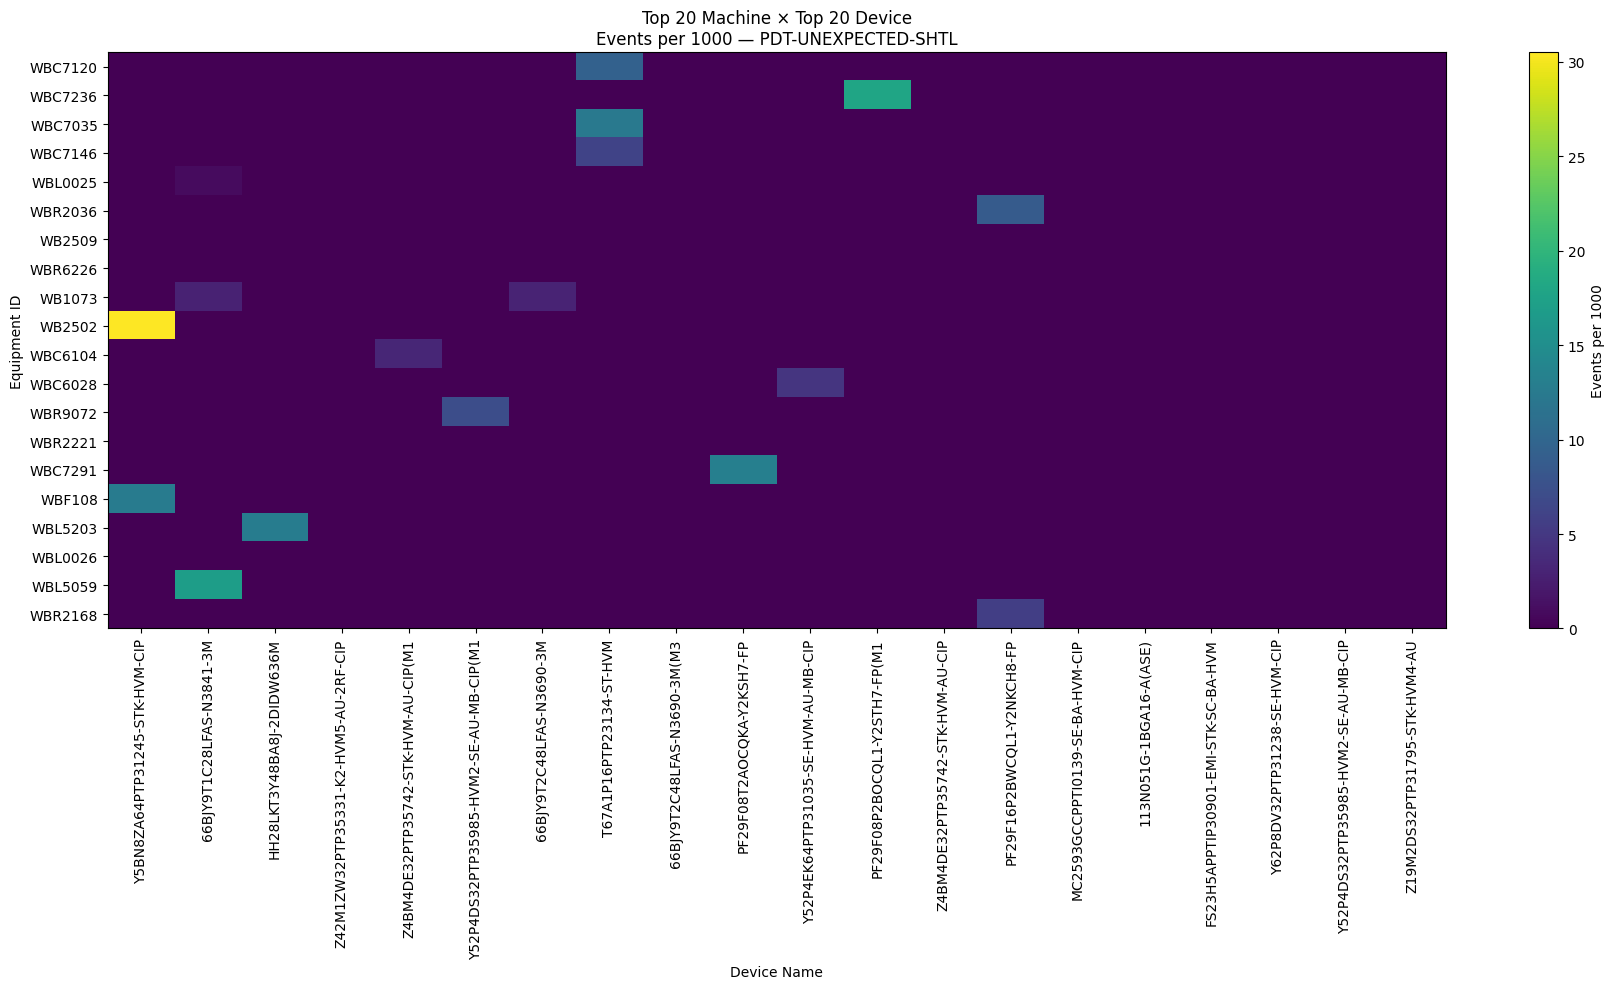

In [62]:
# 1. 找出錯誤總次數最高的 Top 20 機台
top20_machines = (
    machine_device_summary
    .groupby("equip_id")["event_count"]
    .sum()
    .nlargest(20)
    .index
)

# 2. 找出錯誤總次數最高的 Top 20 產品
top20_devices = (
    machine_device_summary
    .groupby("device_name")["event_count"]
    .sum()
    .nlargest(20)
    .index
)

# 3. 只保留 Top 20 機台 × Top 20 產品
heatmap_data = machine_device_summary[
    machine_device_summary["equip_id"].isin(top20_machines)
    & machine_device_summary["device_name"].isin(top20_devices)
].copy()

# 4. 建立 Pivot Table
heatmap_pivot = heatmap_data.pivot(
    index="equip_id",
    columns="device_name",
    values="event_per_1000"
).fillna(0)

# 按照原本 Top 20 排名順序排列
heatmap_pivot = heatmap_pivot.reindex(
    index=top20_machines,
    columns=top20_devices,
    fill_value=0
)

# 5. 畫 Heatmap
fig, ax = plt.subplots(figsize=(18, 10))

image = ax.imshow(
    heatmap_pivot.values,
    aspect="auto"
)

# 設定 X 軸產品名稱
ax.set_xticks(range(len(heatmap_pivot.columns)))
ax.set_xticklabels(
    heatmap_pivot.columns,
    rotation=90
)

# 設定 Y 軸機台名稱
ax.set_yticks(range(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index)

ax.set_xlabel("Device Name")
ax.set_ylabel("Equipment ID")
ax.set_title(
    f"Top 20 Machine × Top 20 Device\n"
    f"Events per 1000 — {event}"
)

# 加入色階說明
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Events per 1000")

plt.tight_layout()
plt.show()

In [60]:
df.loc[(df['equip_id']=='WB2502') & (df['device_name']=='Y5BN8ZA64PTP31245-STK-HVM-CIP')&(df['eventmessage']=='PDT-UNEXPECTED-SHTL')]

,step_id,lot_id,equip_type,equip_id,device_name,recipe_id,in_qty,ng_qty,start_time,end_time,location,floor,eventmessage,eventcount,duration_min,ng_rate
1189,A42,M607V6464.00,IConn,WB2502,Y5BN8ZA64PTP31245-STK-HVM-CIP,SMIM96HGG404-00-AF-00,64,1.000000,2026-07-25 18:56:00,2026-07-28 18:44:00,3A,4F,PDT-UNEXPECTED-SHTL,1.0,4308.0,0.015625
1194,A42,M607V6466.00,IConn,WB2502,Y5BN8ZA64PTP31245-STK-HVM-CIP,SMIM96HGG404-00-AF-00,390,1.500000,2026-07-25 22:47:00,2026-07-28 17:56:00,3A,4F,PDT-UNEXPECTED-SHTL,22.0,4029.0,0.003846
1199,A42,M607W2550.00,IConn,WB2502,Y5BN8ZA64PTP31245-STK-HVM-CIP,SMIM96HGG404-00-AF-00,703,0.666667,2026-07-23 23:26:00,2026-07-26 03:40:00,3A,4F,PDT-UNEXPECTED-SHTL,16.0,3134.0,0.000948
1203,A42,M607X3293.00,IConn,WB2502,Y5BN8ZA64PTP31245-STK-HVM-CIP,SMIM96HGG404-00-AF-00,351,0.333333,2026-07-20 16:01:00,2026-07-23 02:03:00,3A,4F,PDT-UNEXPECTED-SHTL,7.0,3482.0,0.000950
